# Globular Cluster Stream

This example demonstrates how `ezfalcon`  can be used with `galpy` to simulate the formation of a globular cluster tidal stream in the Milky Way.

## Setting up the simulation

We start creating the Milky Way Potential in `galpy`. We'll need it in a second to set up the progenitor.

In [92]:
from galpy.potential import MWPotential2014
host = MWPotential2014[2]

We can go ahead and create our `ezfalcon` `Sim` instance. This class does all of the useful orchestration that we'll need.

In [93]:
from ezfalcon.simulation import Sim
stream = Sim()

We can also add the MW potential using the `add_external_pot` method:

In [94]:
# NOTE: turn physical units on the MW potential first
import astropy.units as u
host.turn_physical_on(ro=8*u.kpc, vo=220*u.km/u.s)
stream.add_external_pot(host)

Let's say we want to drop the progenitor 15 kpc from the center of the Milky Way (R) and 5 kpc above the disk, with a tangential velocity that is 80% of the circular velocity at that point. The speed we need can be calculated in the following way using `galpy`:

In [95]:
center_R = 10 * u.kpc # progenitor center radius
center_z = 0 * u.kpc
import numpy as np
center_r = np.sqrt(center_R**2 + center_z**2)
center_v = host.vcirc(center_r, quantity=True).to(u.km/u.s) * 0.8 # progentior center speed

Next, we sample **20,000** positions, velocities, and masses of the progentior using `ezfalcon`'s integrated interface with `galpy`. 

We sample a King sphere of mass $10^8 \text{M}_{\odot}$, which also requires us to calculate the tidal radius (which we do with galpy).

In [96]:
sat_mass = 1e7 * u.Msun # progenitor mass
rtidal = host.rtide(R=center_R, z=0 * u.kpc, M=sat_mass, quantity=True).to(u.kpc)

from ezfalcon.tools import mkKing_galpy
pos, vel, mass = mkKing_galpy(m=1e7, n = 20000, center_pos = [center_R.value, 0, 0], 
                              center_vel = [0., center_v.value, 0.], W0=4, rt=rtidal.value)

In [97]:
print(f'Each particle has mass {mass[0]} Msun')

Each particle has mass 500.0 Msun


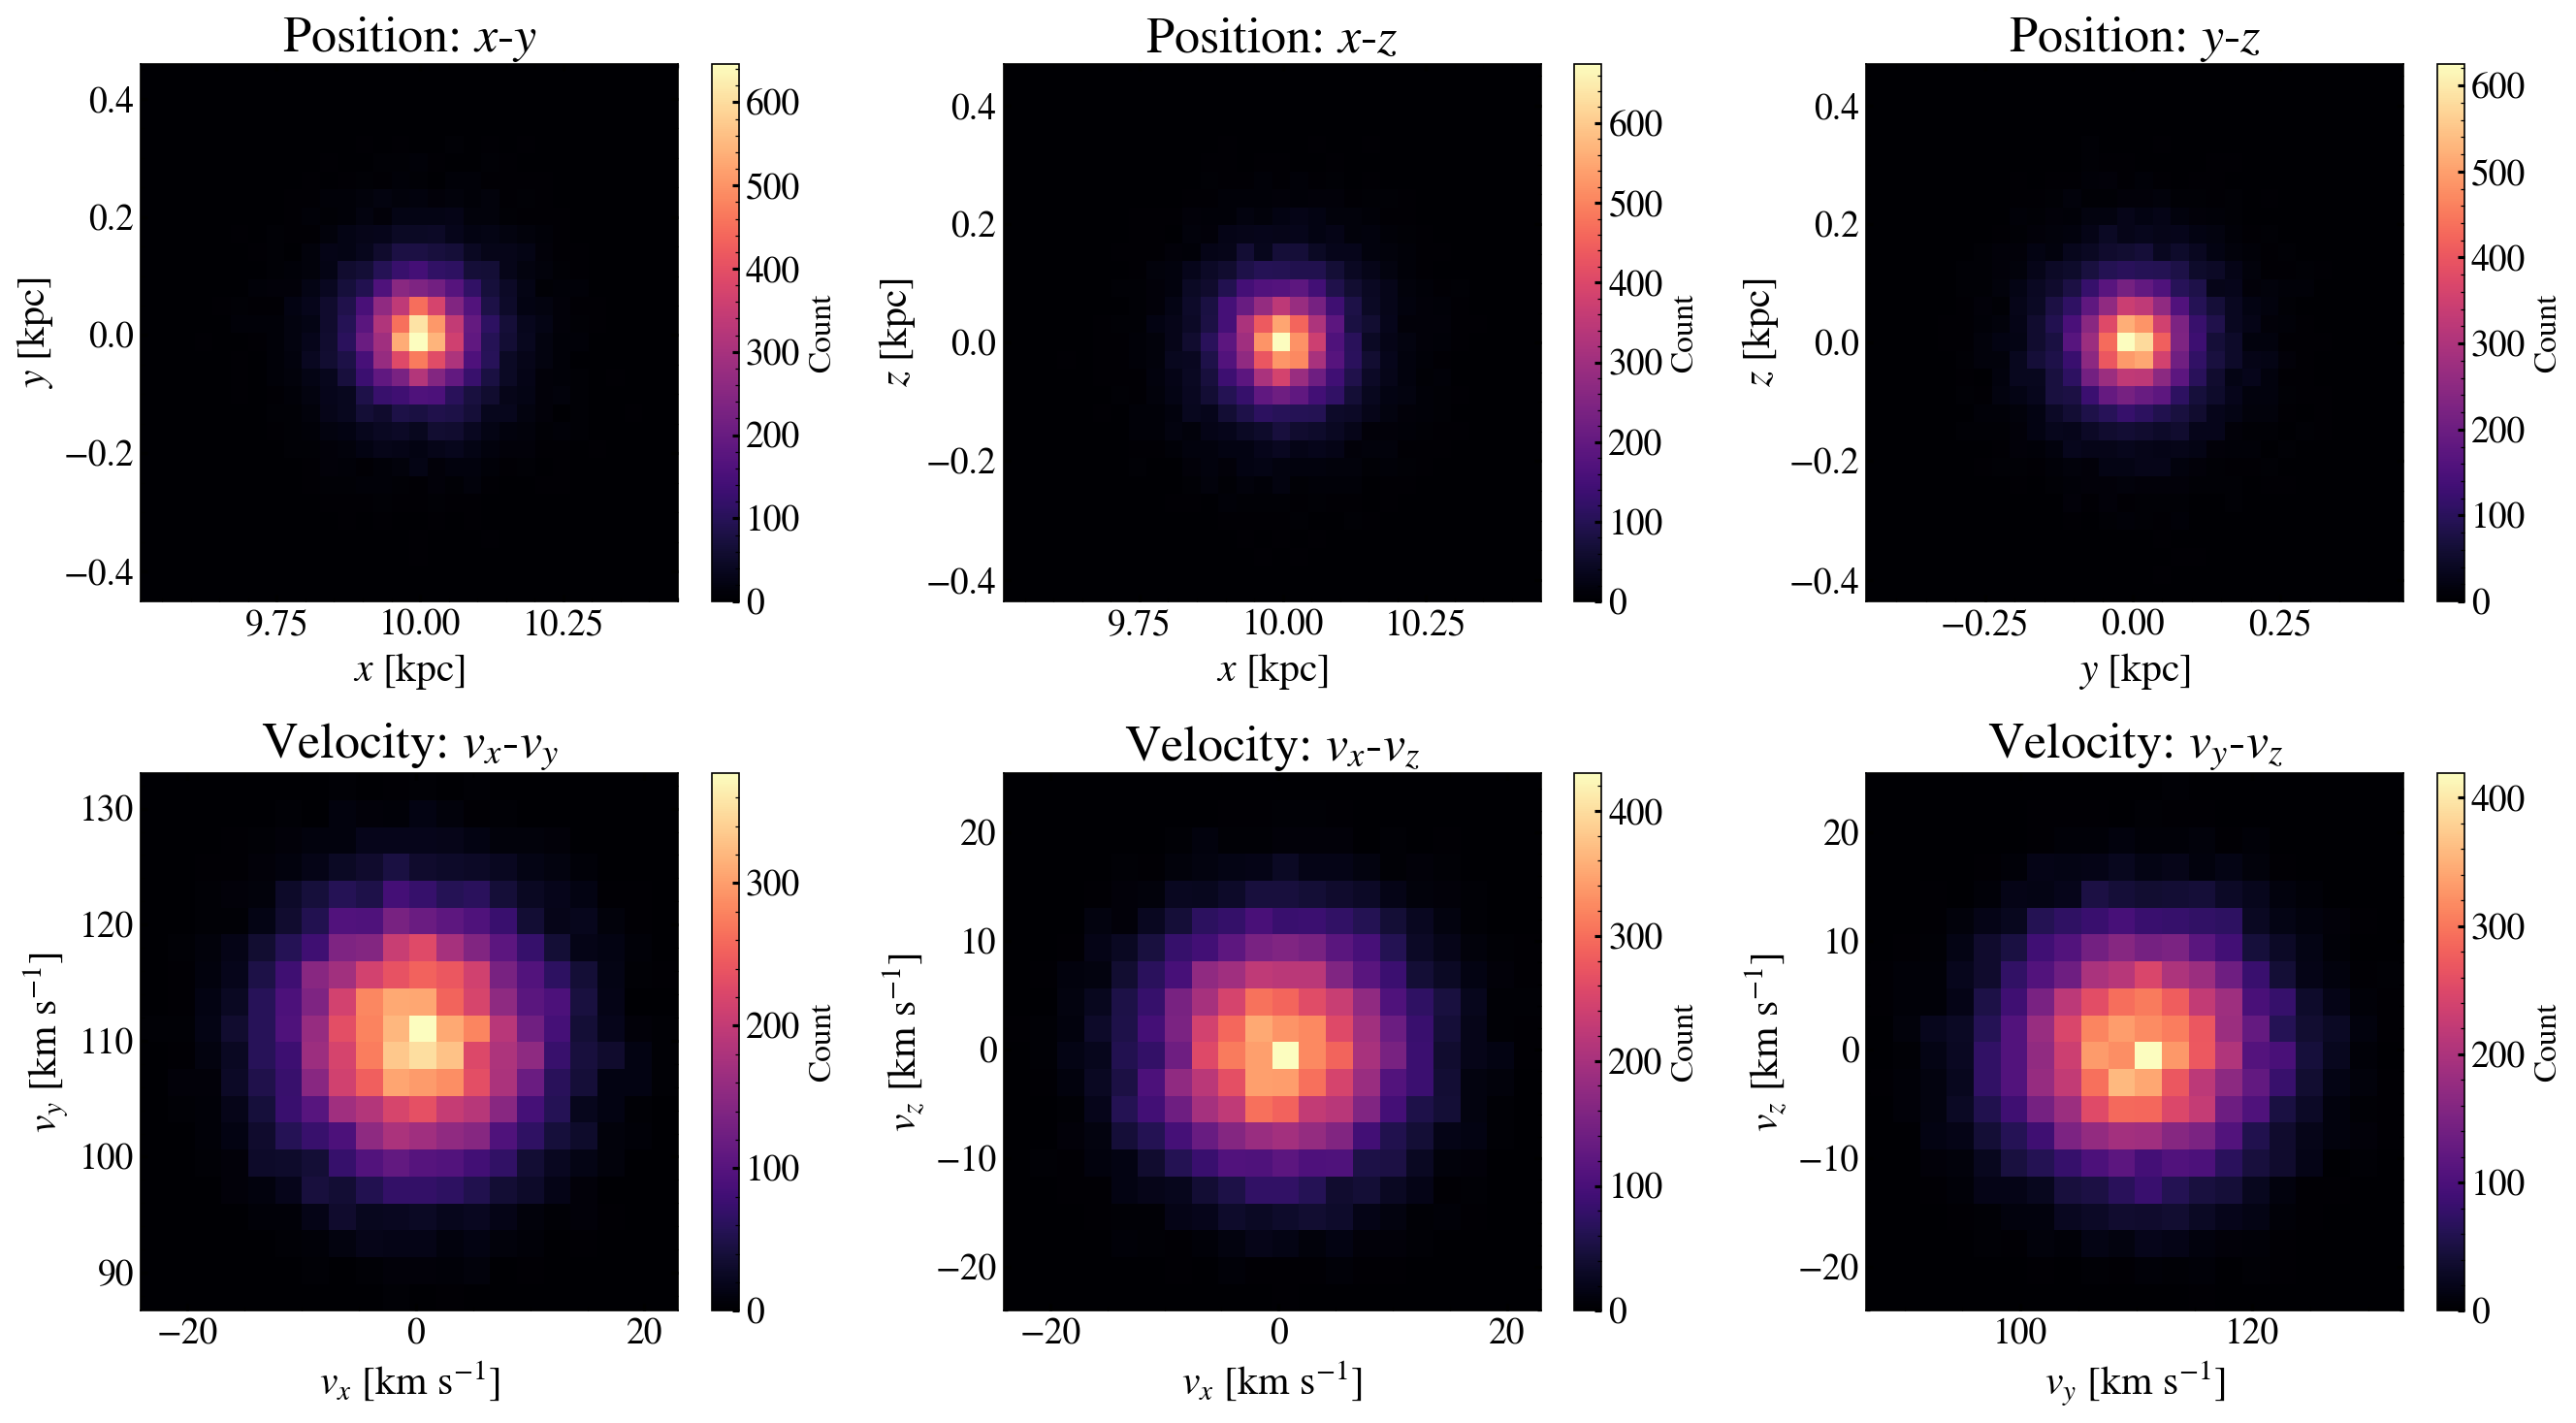

In [98]:
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150)

# --- Top row: position projections ---
h_xy = axes[0, 0].hist2d(pos[:, 0], pos[:, 1], bins=30, cmap='magma')
axes[0, 0].set_xlabel(r'$x$ [kpc]', fontsize=20)
axes[0, 0].set_ylabel(r'$y$ [kpc]', fontsize=20)
axes[0, 0].set_title('Position: $x$-$y$', fontsize=25)
fig.colorbar(h_xy[3], ax=axes[0, 0], label='Count')

h_xz = axes[0, 1].hist2d(pos[:, 0], pos[:, 2], bins=30, cmap='magma')
axes[0, 1].set_xlabel(r'$x$ [kpc]', fontsize=20)
axes[0, 1].set_ylabel(r'$z$ [kpc]', fontsize=20)
axes[0, 1].set_title('Position: $x$-$z$', fontsize=25)
fig.colorbar(h_xz[3], ax=axes[0, 1], label='Count')

h_yz = axes[0, 2].hist2d(pos[:, 1], pos[:, 2], bins=30, cmap='magma')
axes[0, 2].set_xlabel(r'$y$ [kpc]', fontsize=20)
axes[0, 2].set_ylabel(r'$z$ [kpc]', fontsize=20)
axes[0, 2].set_title('Position: $y$-$z$', fontsize=25)
fig.colorbar(h_yz[3], ax=axes[0, 2], label='Count')

# --- Bottom row: velocity projections ---
h_vxvy = axes[1, 0].hist2d(vel[:, 0], vel[:, 1], bins=20, cmap='magma')
axes[1, 0].set_xlabel(r'$v_x$ [km s$^{-1}$]', fontsize=20)
axes[1, 0].set_ylabel(r'$v_y$ [km s$^{-1}$]', fontsize=20)
axes[1, 0].set_title('Velocity: $v_x$-$v_y$', fontsize=25)
fig.colorbar(h_vxvy[3], ax=axes[1, 0], label='Count')

h_vxvz = axes[1, 1].hist2d(vel[:, 0], vel[:, 2], bins=20, cmap='magma')
axes[1, 1].set_xlabel(r'$v_x$ [km s$^{-1}$]', fontsize=20)
axes[1, 1].set_ylabel(r'$v_z$ [km s$^{-1}$]', fontsize=20)
axes[1, 1].set_title('Velocity: $v_x$-$v_z$', fontsize=25)
fig.colorbar(h_vxvz[3], ax=axes[1, 1], label='Count')

h_vyvz = axes[1, 2].hist2d(vel[:, 1], vel[:, 2], bins=20, cmap='magma')
axes[1, 2].set_xlabel(r'$v_y$ [km s$^{-1}$]', fontsize=20)
axes[1, 2].set_ylabel(r'$v_z$ [km s$^{-1}$]', fontsize=20)
axes[1, 2].set_title('Velocity: $v_y$-$v_z$', fontsize=25)
fig.colorbar(h_vyvz[3], ax=axes[1, 2], label='Count')

fig.tight_layout()
plt.show()

And we can add these particles to the simulation with a name using the `add_particles` method:

In [99]:
stream.add_particles('stars', pos=pos, vel=vel, mass=mass)

With the particles added, we can do all sorts of fun stuff, like visualize the self-gravity and external forces/accelerations using the aptly named `self_ax/self_ay/self_az` and `external_ax/external_ay/external_az` methods

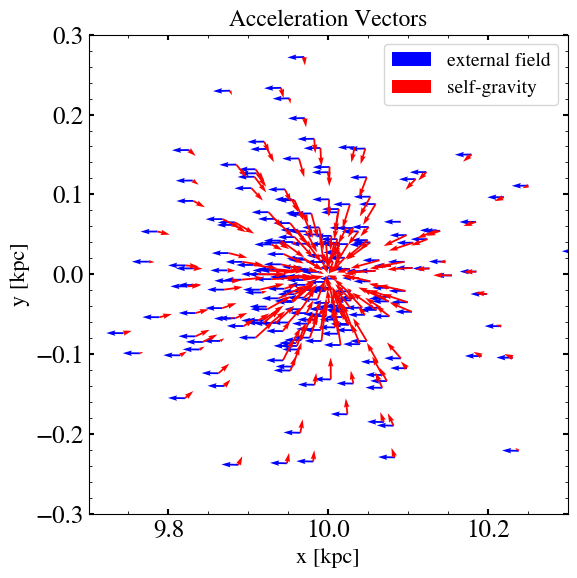

In [113]:
skip_every = 80
fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(stream.x(0)[::skip_every], stream.y(0)[::skip_every], 
          stream.external_ax(0)[::skip_every], stream.external_ay(0)[::skip_every], 
          alpha=1, color='b', label='external field')
ax.quiver(stream.x(0)[::skip_every], stream.y(0)[::skip_every], 
          stream.self_ax(0, method='falcON', eps=0.01)[::skip_every], 
          stream.self_ay(0, method='falcON', eps=0.01)[::skip_every], 
          alpha=1, color='r', label='self-gravity')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_title('Acceleration Vectors')
ax.set_aspect('equal')
plt.tight_layout()
plt.xlim(9.7, 10.3)
plt.ylim(-0.3, 0.3)
plt.legend()

plt.show()

## Running the simulation

Next, the `run` method evolves the particles under the influence of self-gravity and the external potential for **1.5 Gyr**. I elect to compute self-gravity with `falcON` here.

Runs in **~2 minutes**

In [109]:
stream.run(t_end = 1.5, dt = 0.0005, dt_out=0.01, method='falcON', eps=0.01)

  0%|          | 0/3000 [00:00<?, ?it/s]

100%|██████████| 3000/3000 [02:00<00:00, 24.81it/s]


And it's a stream! 

Text(0, 0.5, '$y$ [kpc]')

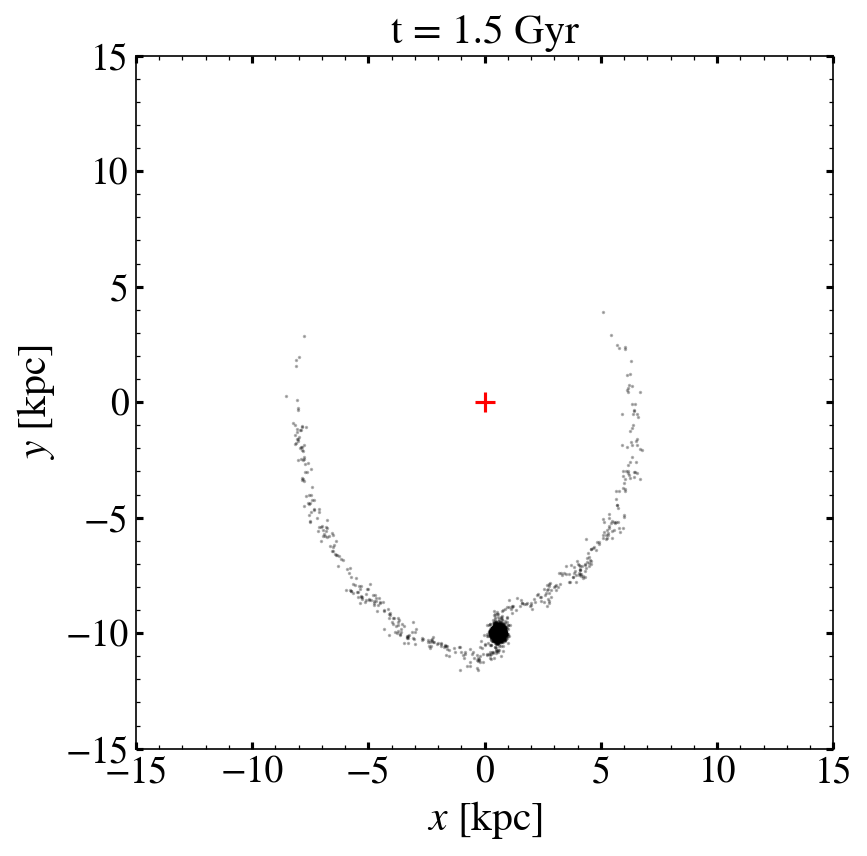

In [110]:
plt.figure(figsize=(6, 6), dpi=150)
plt.scatter(stream.x(-1), stream.y(-1), s=0.4, c='k', alpha=0.3)
plt.scatter(0, 0, s=100, c='r', marker='+')
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.title(f't = {stream.times[-1]:.1f} Gyr', fontsize=20)
plt.xlabel(r'$x$ [kpc]', fontsize=20)
plt.ylabel(r'$y$ [kpc]', fontsize=20)

## Checking Performance

We can also check how well energy is conserved in a few different ways. We can check using the values calculated during integration:

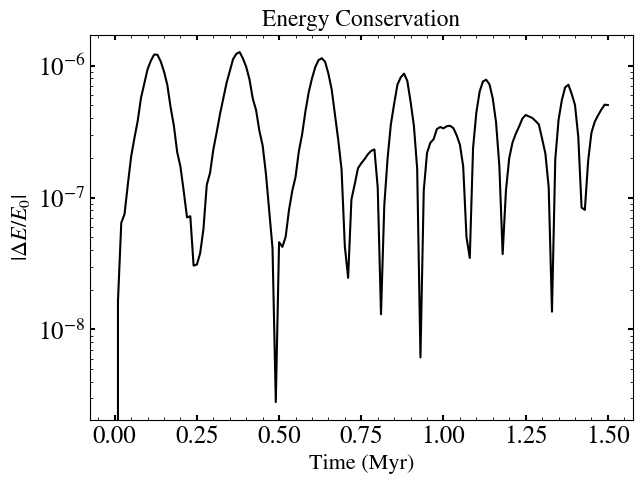

In [111]:
stream.plot_energy_diagnostic()

Or with a different method:

(In this case, I calculate it with direct summation to ensure that the approximation is precise)

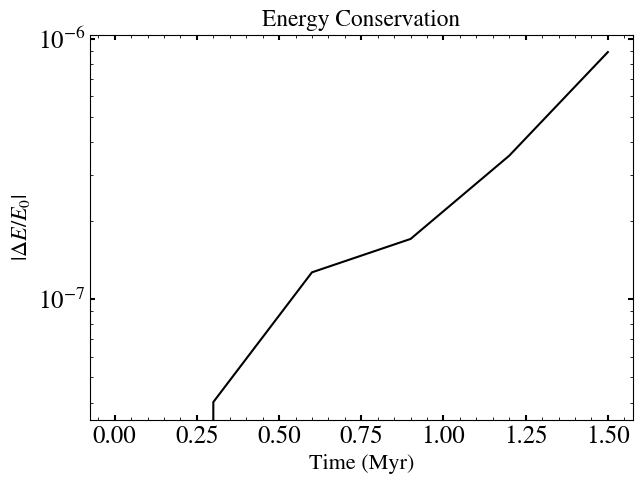

In [114]:
# direct summation is expensive, so only 
# calculate at 10 snapshots. Runs in ~5.5 minutes

stream.plot_energy_diagnostic(method='direct_C', eps=0.01, nsnap=5)

In [117]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlabel(r'$x$ [kpc]', fontsize=20)
ax.set_ylabel(r'$y$ [kpc]', fontsize=20)
ax.set_aspect('equal')
n_snaps = len(stream.times)
skip = 1

def update(frame):
    ax.clear()
    idx = frame * skip
    ax.scatter(stream.x(idx), stream.y(idx), s=0.1, c='k', alpha=0.5)
    ax.scatter(0, 0, s=100, c='r', marker='+')
    ax.set_xlim(-20, 20)
    ax.set_ylim(-20, 20)
    ax.set_title(f't = {stream.times[idx]:.2f} Gyr')
    ax.set_aspect('equal')

ani = FuncAnimation(fig, update, frames=n_snaps // skip, interval=100)
fig.tight_layout()
ani.save(
    '_figures/EX3/GC_stream_evolution.mp4',
    fps=15
)
ani.save(
    '_figures/EX3/GC_stream_evolution.gif',
    fps=15
)
# HTML(ani.to_jshtml())
plt.close(fig)